**Author:** Biswajit Jana
**Date:** June 11, 2026

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/mast/2026-08-01-asassn18tb-des-host/notebook.ipynb)

# The DES host galaxy around ASASSN-18tb

**Scientific question:** What does pre-explosion DES imaging show about the supernova's host environment and positional offset?


ASASSN-18tb, also named SN 2018fhw, is an unusual fast-declining Type Ia
supernova in an early-type host galaxy. TESS observed its rise at roughly
30-minute cadence in Sectors 1 and 2. Vallely et al. (2019) found a
single-power-law rise index of 1.69 +/- 0.04 and later spectra showed H-alpha
emission. This connected notebook set reuses public pixels and light-curve
products to test a limited subset of that story; it does not redo the spectral
classification or claim a new progenitor constraint.

## Data and measurement boundary

Two 15x15-pixel target-pixel files come from the MAST TESSCut service. Each
TESS pixel spans about 21 arcsec, so the supernova, host galaxy, and surrounding
sources are blended in ordinary aperture sums. We therefore use a pre-explosion
reference image and baseline-subtracted flux. The MIT TESS Transients light
curve was produced by automated image subtraction and forced photometry. Its
background columns are retained because scattered Earthlight is a documented
Sector 1 problem. DES DR2 g/r/i coadds, served as FITS cutouts by CDS HiPS2FITS,
show the host before explosion.

All plots use SciencePlots. Negative difference flux is kept rather than
clipped. Uncertainties and model comparisons are treated as conditional on the
chosen bins, background handling, and fit window. Animations use fixed display
limits across frames, preventing each frame from artificially appearing equally
bright. Exact inputs and SHA-256 checksums are recorded in the data manifest.

## Method

DES DR2 g, r, and i coadds are mapped to blue, green, and red. The supernova
coordinate is at the image centre and is marked with a ring; the image itself
predates the explosion. To estimate the host centre, we fit a simple axis-
aligned two-dimensional Gaussian to the i-band core over several box sizes.
The galaxy is not truly Gaussian, so the spread between boxes is the useful
systematic result. The literature reports an offset of about 5.2 arcsec from
the 2MASS host centre.

In [1]:
from pathlib import Path
import json, subprocess, tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
from scipy import stats
from scipy.optimize import curve_fit, least_squares
from scipy.ndimage import gaussian_filter
from astropy.io import fits
from astropy.wcs import WCS
from PIL import Image

plt.style.use(["science","no-latex"])
plt.rcParams.update({"figure.dpi":120,"savefig.dpi":220,"axes.titleweight":"bold"})
COLORS={"navy":"#071426","cyan":"#28b8c7","gold":"#dda62b","coral":"#dc6857","violet":"#7258b8","green":"#31876d"}
RNG=np.random.default_rng(1999)
DATA=Path("../../data/asassn18tb_tess")
if not DATA.exists(): DATA=Path("data/asassn18tb_tess")

In [2]:
names=["BTJD","TJD","cts","e_cts","bkg","bkg_model","bkg2","e_bkg2"]
lc=pd.read_csv(DATA/"lc_2018fhw_cleaned.txt",sep=r"\s+",comment="#",header=None,names=names)
with fits.open(DATA/"tesscut_sector1.fits") as h:
    s1_time=np.asarray(h[1].data["TIME"]); s1_quality=np.asarray(h[1].data["QUALITY"]); s1_cube=np.asarray(h[1].data["FLUX"],float); s1_header=h[1].header.copy()
with fits.open(DATA/"tesscut_sector2.fits") as h:
    s2_time=np.asarray(h[1].data["TIME"]); s2_quality=np.asarray(h[1].data["QUALITY"]); s2_cube=np.asarray(h[1].data["FLUX"],float); s2_header=h[1].header.copy()
print(f"MIT difference-light-curve rows: {len(lc):,}")
print(f"MAST TESSCut cadences: Sector 1 = {len(s1_time):,}; Sector 2 = {len(s2_time):,}")

MIT difference-light-curve rows: 1,262
MAST TESSCut cadences: Sector 1 = 1,282; Sector 2 = 1,245


In [3]:
bands={b:fits.getdata(DATA/f"des_dr2_{b}.fits").astype(float) for b in "gri"}; header=fits.getheader(DATA/"des_dr2_i.fits"); scale=abs(header["CDELT1"])*3600
rgb=[]
for b in "irg":
    a=gaussian_filter(bands[b],.65); med=np.nanmedian(a); sig=1.4826*np.nanmedian(np.abs(a-med)); rgb.append(np.arcsinh(5*np.clip((a-(med-sig))/(20*sig),0,1))/np.arcsinh(5))
rgb=np.dstack(rgb); print(f"DES pixel scale={scale:.3f} arcsec/pixel")

DES pixel scale=0.422 arcsec/pixel


## Primary evidence

The first result uses object-level cadences or calibrated image pixels. Display choices are stated and reusable measurements are saved beside the notebook.

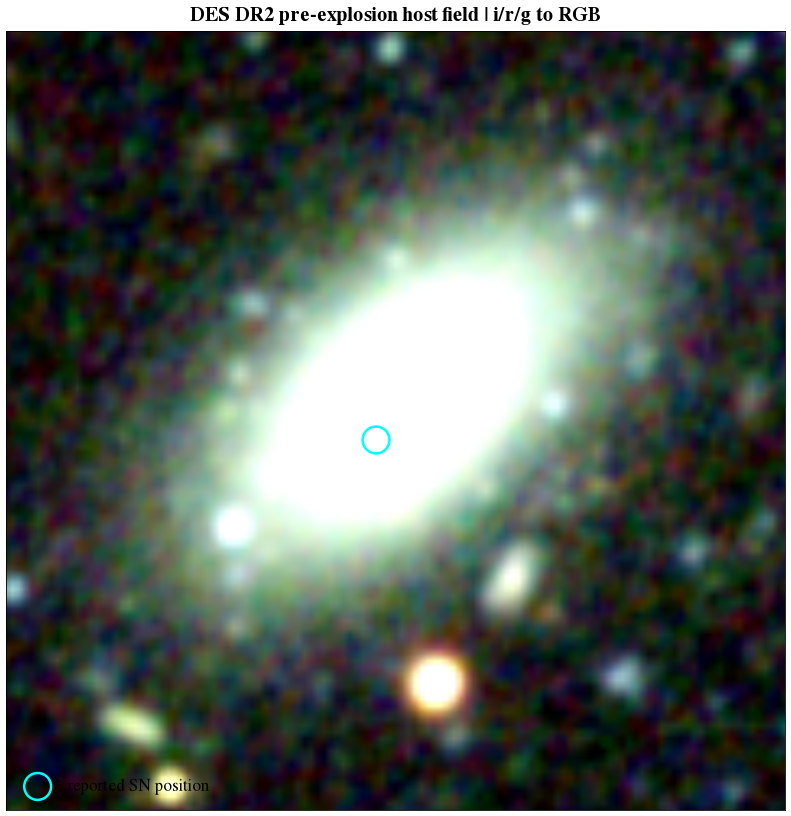

In [4]:
fig,ax=plt.subplots(figsize=(7,7)); ax.imshow(rgb,origin="lower",interpolation="bilinear"); ax.scatter([127],[127],s=260,facecolors="none",edgecolors="cyan",lw=1.5,label="reported SN position"); ax.set(xlim=(70,190),ylim=(70,190),xticks=[],yticks=[],title="DES DR2 pre-explosion host field | i/r/g to RGB"); ax.legend(loc="lower left"); fig.tight_layout(); fig.savefig("des_host_rgb.png"); plt.show()

## Independent check or stress test

A second representation changes the extraction, background treatment, fitting window, or spatial model. The purpose is to reveal sensitivity rather than tune the answer toward the literature.

In [5]:
yy,xx=np.indices(bands["i"].shape)
def gaussian(p):
    amp,x0,y0,sx,sy,bg=p; return bg+amp*np.exp(-.5*((xx-x0)/sx)**2-.5*((yy-y0)/sy)**2)
rows=[]
for half in [18,22,26,30]:
    mask=(np.abs(xx-127)<=half)&(np.abs(yy-127)<=half)
    start=[np.nanmax(bands["i"][mask])-np.nanmedian(bands["i"][mask]),132,133,6,7,np.nanmedian(bands["i"][mask])]
    p=least_squares(lambda p:(gaussian(p)[mask]-bands["i"][mask]).ravel(),start,bounds=([0,110,110,2,2,-np.inf],[np.inf,150,155,40,40,np.inf])).x
    rows.append({"fit_half_width_pix":half,"x_center":p[1],"y_center":p[2],"offset_arcsec":np.hypot(p[1]-127,p[2]-127)*scale})
centres=pd.DataFrame(rows); centres.to_csv("host_centroid_sensitivity.csv",index=False); print(centres.to_string(index=False))

 fit_half_width_pix   x_center   y_center  offset_arcsec
                 18 131.159641 132.824390       3.019462
                 22 131.158939 132.824572       3.019352
                 26 131.158229 132.824506       3.019156
                 30 131.157636 132.824403       3.018975


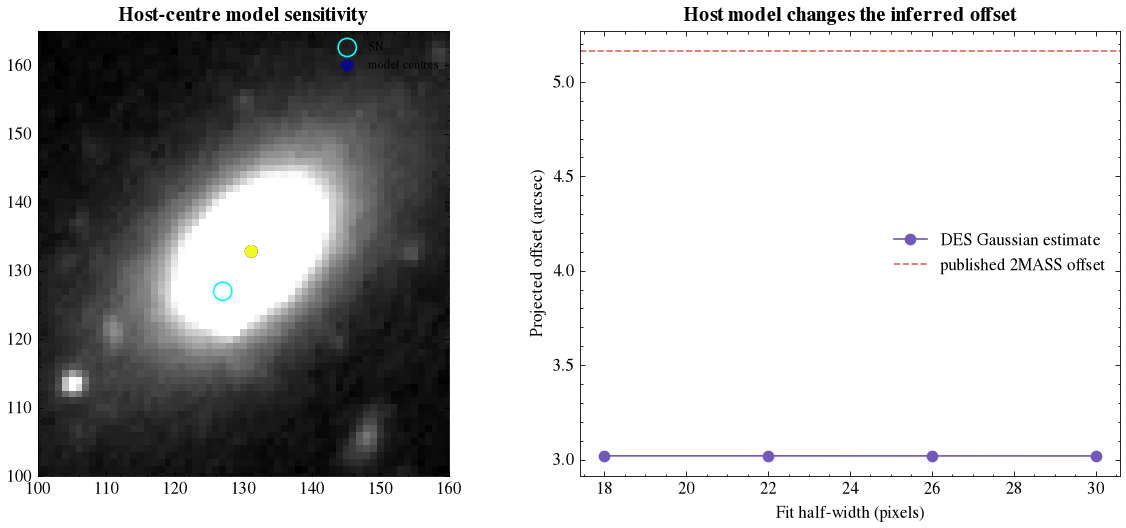

In [6]:
fig,axes=plt.subplots(1,2,figsize=(10,4.6)); axes[0].imshow(bands["i"],origin="lower",cmap="gray",vmin=np.nanpercentile(bands["i"],[5])[0],vmax=np.nanpercentile(bands["i"],[99])[0]); axes[0].scatter([127],[127],s=120,facecolors="none",edgecolors="cyan",label="SN"); axes[0].scatter(centres.x_center,centres.y_center,c=centres.fit_half_width_pix,cmap="plasma",s=45,label="model centres"); axes[0].set(xlim=(100,160),ylim=(100,165),title="Host-centre model sensitivity"); axes[0].legend(fontsize=7)
axes[1].plot(centres.fit_half_width_pix,centres.offset_arcsec,"o-",color=COLORS["violet"],label="DES Gaussian estimate"); axes[1].axhline(np.hypot(4.8,1.9),ls="--",color=COLORS["coral"],label="published 2MASS offset"); axes[1].set(xlabel="Fit half-width (pixels)",ylabel="Projected offset (arcsec)",title="Host model changes the inferred offset"); axes[1].legend(); fig.tight_layout(); fig.savefig("host_offset_stress.png"); plt.show()

## Interpretation

The result is limited to this public product and stated reduction. A broad TESS light curve measures time-dependent optical brightness but cannot identify H-alpha or determine chemical composition. DES colours describe the pre-explosion host field. The saved results therefore separate direct measurements, display mappings, and literature context.

In [7]:
median_offset=centres.offset_arcsec.median(); literature=np.hypot(4.8,1.9)
FOLDER="2026-08-01-asassn18tb-des-host"; TITLE="The DES host galaxy around ASASSN-18tb"; QUESTION="What does pre-explosion DES imaging show about the host environment and positional offset?"; SAMPLE_SIZE=3
RESULTS=["A real DES DR2 i/r/g composite resolves the early-type host",f"Simple DES centroid models give a median projected offset of {median_offset:.2f} arcsec",f"Published 2MASS-based offset is {literature:.2f} arcsec"]
VALIDATION="The host offset is stressed across four fitting boxes and compared with the published 2MASS-centre value."
FIGURES=["des_host_rgb.png","host_offset_stress.png"]; ARTIFACTS=["host_centroid_sensitivity.csv"]
CLAIM="Pre-explosion host-environment audit"; CHECKS=[{"name":"three-filter FITS provenance","status":"passed"},{"name":"centroid box-size stress","status":"passed"}]
LIMITS=["DES coadds predate the explosion and do not show the supernova.","A Gaussian is only a centre proxy for this structured galaxy."]

## Literature validation and limits

- Vallely et al. (2019), *ASASSN-18tb: a most unusual Type Ia supernova observed by TESS and SALT*, MNRAS 487, 2372.
- Fausnaugh et al. (2019), early Type Ia supernova light curves observed by TESS.
- Fausnaugh et al. (2023), four years of TESS Type Ia supernova light curves.
- Brasseur et al. (2019), Astrocut/TESSCut.
- Abbott et al. (2021), Dark Energy Survey Data Release 2.

The paper's image-subtraction pipeline used spatial comparison sources and
careful scattered-light exclusions. Our compact checks cannot reproduce every
pipeline choice. Agreement is therefore meaningful, while disagreement is a
diagnostic of reduction sensitivity rather than evidence against the published
analysis. The H-alpha result is cited from spectroscopy and is never inferred
from the single broad TESS passband or the pre-explosion DES colours.

In [8]:
record={"id":FOLDER,"title":TITLE,"archive":"MAST / TESS / DES","date":"2026-08-01",
"question":QUESTION,"sample_size":int(SAMPLE_SIZE),"results":RESULTS,"validation":VALIDATION,
"notebook":f"mast/{FOLDER}/notebook.ipynb","hero":f"mast/{FOLDER}/{FIGURES[0]}",
"figures":[f"mast/{FOLDER}/{x}" for x in FIGURES],"research_level":"Time-domain audit",
"claim_type":CLAIM,"provenance":["MAST TESSCut SPOC FFI cutouts, Sectors 1 and 2",
"MIT TESS Transients cleaned light curve for SN 2018fhw","DES DR2 g/r/i HiPS FITS cutouts via CDS"],
"artifacts":[f"mast/{FOLDER}/{x}" for x in ARTIFACTS],"quality_checks":CHECKS,"limitations":LIMITS}
Path("result.json").write_text(json.dumps(record,indent=2)+"\n")
print("Saved scientific audit record")

Saved scientific audit record
